# Import required libraries

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATASET

In [92]:
df = pd.read_csv('Iris.csv')

# 2. INSPECT

In [93]:
print("=" * 55)
print("  IRIS DATASET — EXPLORATION REPORT")
print("=" * 55)
 
print(f"\n📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")
 
print("\n── .head() ──")
print(df.head())
 
print("\n── .info() ──")
df.info()
 
print("\n── .describe() ──")
print(df.describe().round(2))
 
print("\n── Species Value Counts ──")
print(df['Species'].value_counts())

  IRIS DATASET — EXPLORATION REPORT

📐 Shape: 150 rows × 6 columns

📋 Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

── .head() ──
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

── .info() ──
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null

# 3. SETUP

In [94]:
PALETTE = {
    'Iris-setosa':     '#4C72B0',
    'Iris-versicolor': '#55A868',
    'Iris-virginica':  '#C44E52',
}
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
labels   = ['Sepal Length (cm)', 'Sepal Width (cm)',
            'Petal Length (cm)', 'Petal Width (cm)']
BG, GRID = '#F8F9FB', '#E2E5EC'

# 4- VISUALIZATIONS

In [95]:
# Create figure with subplots
fig = plt.figure(figsize=(20, 15))

<Figure size 2000x1500 with 0 Axes>

# 5. SCATTER PLOT MATRIX 

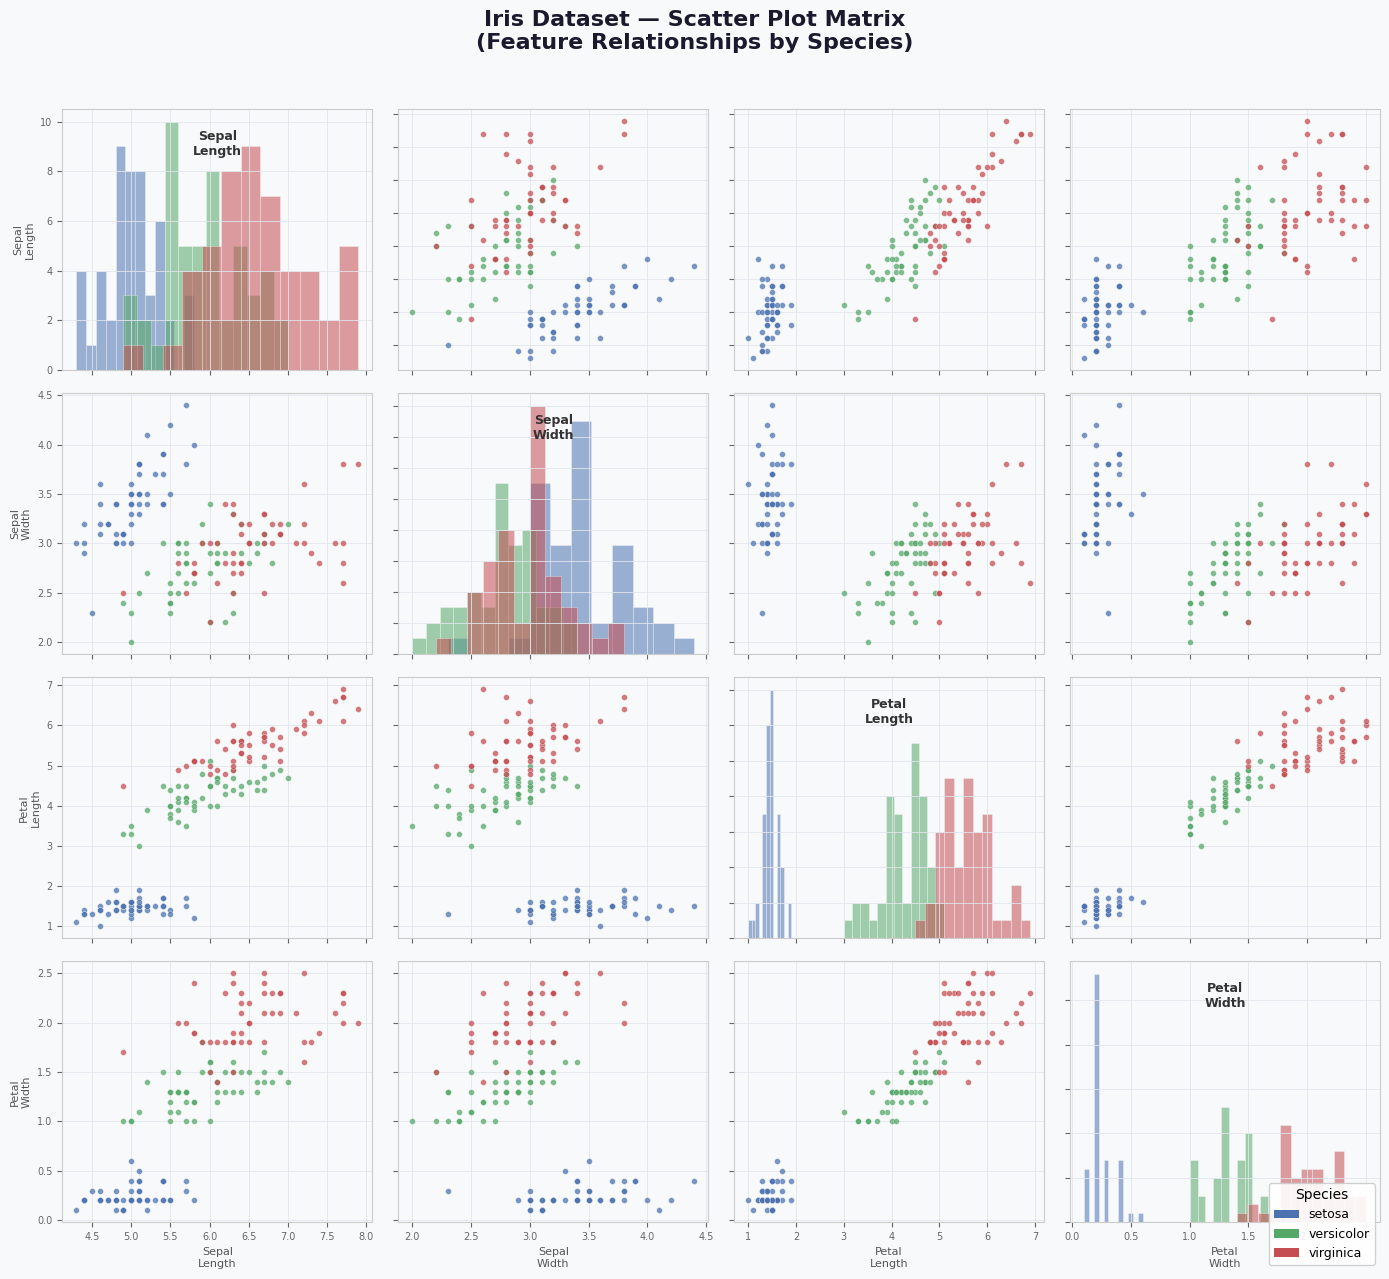

In [96]:
short = ['Sepal\nLength', 'Sepal\nWidth', 'Petal\nLength', 'Petal\nWidth']
fig1, axes = plt.subplots(4, 4, figsize=(14, 13))
fig1.patch.set_facecolor(BG)
fig1.suptitle('Iris Dataset — Scatter Plot Matrix\n(Feature Relationships by Species)',
              fontsize=16, fontweight='bold', y=0.98, color='#1a1a2e')
 
for i, fx in enumerate(features):
    for j, fy in enumerate(features):
        ax = axes[i][j]
        ax.set_facecolor(BG)
        ax.grid(True, color=GRID, linewidth=0.6, zorder=0)
        for spine in ax.spines.values():
            spine.set_color('#cccccc')
        if i == j:
            for sp, col in PALETTE.items():
                ax.hist(df[df['Species'] == sp][fx], bins=12,
                        color=col, alpha=0.55, edgecolor='white', linewidth=0.4)
            ax.text(0.5, 0.92, short[i], transform=ax.transAxes,
                    ha='center', va='top', fontsize=9, fontweight='bold', color='#333')
        else:
            for sp, col in PALETTE.items():
                sub = df[df['Species'] == sp]
                ax.scatter(sub[fy], sub[fx], color=col, s=18, alpha=0.75,
                           edgecolors='white', linewidths=0.3, zorder=3)
        if i == 3: ax.set_xlabel(short[j], fontsize=8, color='#555')
        else:      ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(short[i], fontsize=8, color='#555')
        else:      ax.set_yticklabels([])
        ax.tick_params(labelsize=7, colors='#666')
 
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=sp.replace('Iris-',''))
           for sp, c in PALETTE.items()]
fig1.legend(handles=handles, title='Species', title_fontsize=10, fontsize=9,
            loc='lower right', bbox_to_anchor=(0.99, 0.01),
            framealpha=0.9, edgecolor='#ccc')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


# 6. BOX PLOTS


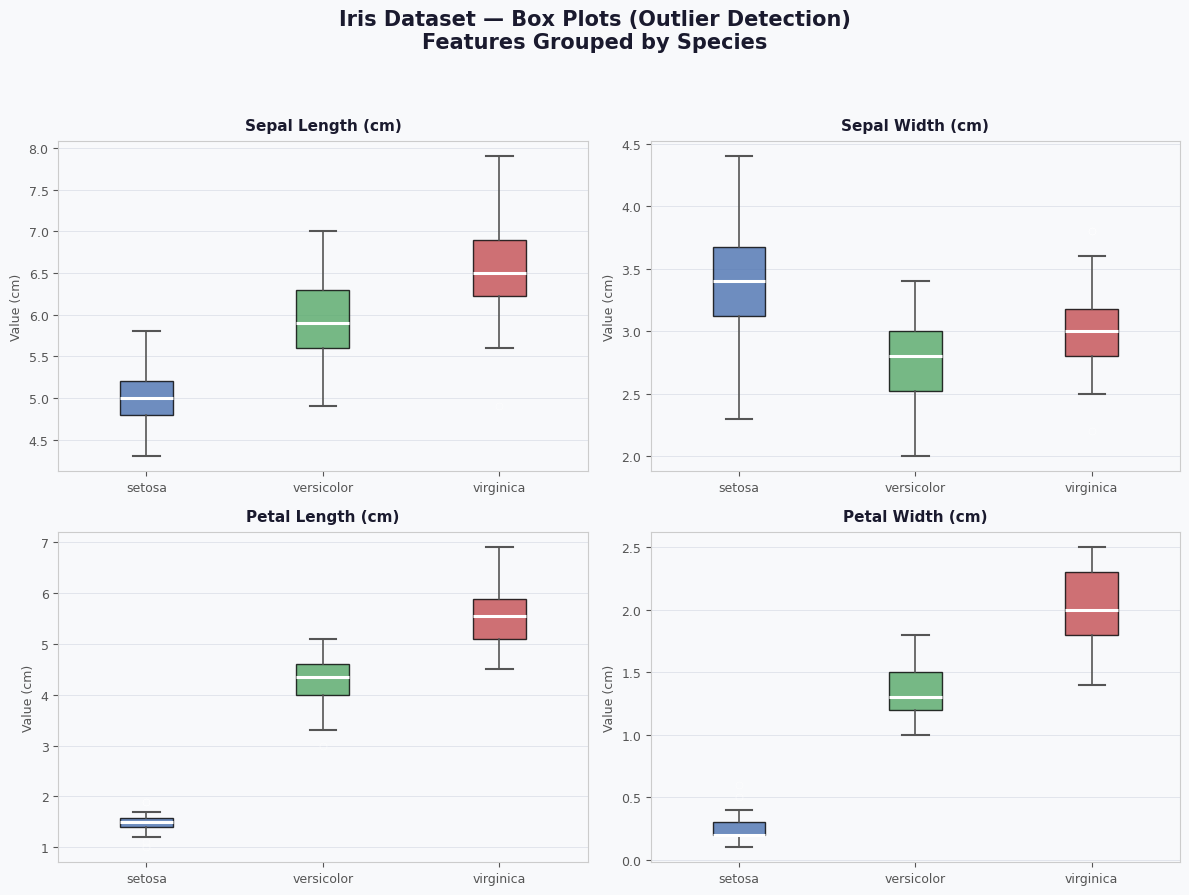


✅ All plots saved: scatter_plots.png, histograms.png, box_plots.png


In [90]:
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9))
fig3.patch.set_facecolor(BG)
fig3.suptitle('Iris Dataset — Box Plots (Outlier Detection)\nFeatures Grouped by Species',
              fontsize=15, fontweight='bold', y=0.99, color='#1a1a2e')
 
species_order = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
xtick_labels  = ['setosa', 'versicolor', 'virginica']
colors_list   = list(PALETTE.values())
 
for idx, (feat, lbl) in enumerate(zip(features, labels)):
    ax = axes3.flatten()[idx]
    ax.set_facecolor(BG)
    ax.grid(True, axis='y', color=GRID, linewidth=0.7, zorder=0)
    data_by_sp = [df[df['Species'] == sp][feat].values for sp in species_order]
    bp = ax.boxplot(data_by_sp, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.2),
                    whiskerprops=dict(linewidth=1.2, color='#555'),
                    capprops=dict(linewidth=1.5, color='#555'),
                    flierprops=dict(marker='o', markersize=5, alpha=0.7,
                                   markeredgewidth=0.5, markeredgecolor='white'))
    for patch, col in zip(bp['boxes'], colors_list):
        patch.set_facecolor(col); patch.set_alpha(0.80)
    ax.set_title(lbl, fontsize=11, fontweight='semibold', pad=8, color='#1a1a2e')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_ylabel('Value (cm)', fontsize=9, color='#555')
    ax.tick_params(labelsize=9, colors='#555')
    for spine in ax.spines.values(): spine.set_color('#ccc')
 
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('box_plots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
 
print("\n✅ All plots saved: scatter_plots.png, histograms.png, box_plots.png")